# 🏒 VIZER NHL — 02 · Agrégation & Feature Engineering

Construit `dataset_agrege_vizer_nhl.csv` depuis les CSVs bruts Moneypuck.

**Pipeline :**
1. Normalisation des codes équipe (TEAM_REMAP)
2. Chargement gardiens / skaters / lignes / équipes
3. PP/PK sur vraies situations (5on4 / 4on5)
4. Rolling stats multi-fenêtres (5 / 10 / 20 matchs)
5. PDO glissant par ratio de sommes
6. Différentiels Home vs Away
7. Correction SO pour `home_team_won`
8. Validation automatique

In [10]:
import os
# Chemin racine des données (CSVs téléchargés par 01_Maintenance)
DRIVE_PATH = '/home/noxtheteenager/Documents/Projets/vizer_info_model/hockey/nhl'

import sys, os
sys.path.insert(0, '.')  # S'assurer que vizer_utils.py est trouvable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from vizer_utils import normalize_teams, TEAM_REMAP

# ── Chemins ───────────────────────────────────────────────────────────────────
TEAM_DATA    = 'all_teams.csv'
GOALIES_HIST = 'goalies_2008_2024.csv'
GOALIES_2025 = 'goalies_2025.csv'
LINES_HIST   = 'lines_2008_2024.csv'
LINES_2025   = 'lines_2025.csv'
SKATERS_HIST = 'skaters_2008_2024.csv'
SKATERS_2025 = 'skaters_2025.csv'
OUTPUT_DATASET = 'dataset_agrege_vizer_nhl.csv'

print('✅ Imports OK — démarrage de l\'agrégation V5')

✅ Imports OK — démarrage de l'agrégation V5


## 🧤 Étape 1 — Gardiens

🧤 Chargement des gardiens...
   Gardiens : 43,199 entrées matchs | GSAE moyen : 0.057


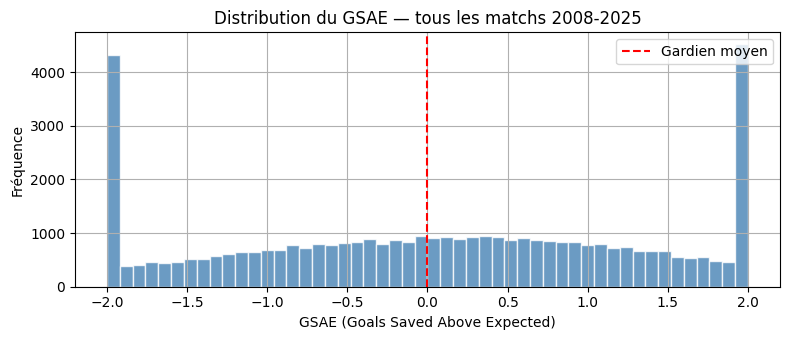

In [11]:
print('🧤 Chargement des gardiens...')
df_g = pd.concat([pd.read_csv(GOALIES_HIST), pd.read_csv(GOALIES_2025)], ignore_index=True)
df_g = normalize_teams(df_g)
df_g['GSAE'] = df_g['xGoals'] - df_g['goals']
df_g = (df_g[df_g['situation'] == 'all']
        .sort_values(['gameId', 'icetime'], ascending=[True, False])
        .drop_duplicates(subset=['gameId', 'playerTeam'])
        .rename(columns={'playerTeam': 'team', 'name': 'goalie_name'}))

print(f'   Gardiens : {len(df_g):,} entrées matchs | GSAE moyen : {df_g["GSAE"].mean():.3f}')

# Visualisation distribution GSAE
fig, ax = plt.subplots(figsize=(8, 3.5))
df_g['GSAE'].clip(-2, 2).hist(bins=50, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Gardien moyen')
ax.set_xlabel('GSAE (Goals Saved Above Expected)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution du GSAE — tous les matchs 2008-2025')
ax.legend()
plt.tight_layout()
plt.show()

## ⛸️ Étape 2 — Skaters & Lignes

In [12]:
import gc

print('⛸️  Chargement des skaters...')
df_s = pd.concat([pd.read_csv(SKATERS_HIST), pd.read_csv(SKATERS_2025)], ignore_index=True)
df_s = normalize_teams(df_s)
df_s = df_s[df_s['situation'] == 'all'].copy()
df_s['star_impact'] = df_s['onIce_xGoalsPercentage'] - df_s['offIce_xGoalsPercentage']

df_s_agg = df_s.groupby(['gameId', 'playerTeam']).agg({
    'star_impact':    'mean',
    'I_F_takeaways':  'sum',
    'I_F_giveaways':  'sum',
    'penaltiesDrawn': 'sum',
}).reset_index()
df_s_agg['net_takeaways'] = df_s_agg['I_F_takeaways'] - df_s_agg['I_F_giveaways']
df_s_agg = df_s_agg.rename(columns={'playerTeam': 'team'})
del df_s; gc.collect()

print('🏒 Chargement des lignes...')
df_l = pd.concat([pd.read_csv(LINES_HIST), pd.read_csv(LINES_2025)], ignore_index=True)
df_l = normalize_teams(df_l).copy()
df_l['panic_score'] = df_l['dZoneGiveawaysAgainst'] / (df_l['icetime'] / 60 + 0.001)

df_l_top = (df_l[df_l['iceTimeRank'] <= 2]
            .groupby(['gameId', 'playerTeam'])
            .agg({'xGoalsPercentage': 'mean', 'corsiPercentage': 'mean', 'panic_score': 'mean'})
            .reset_index()
            .rename(columns={
                'playerTeam':       'team',
                'xGoalsPercentage': 'top_line_xGF',
                'corsiPercentage':  'corsi_eff',
            }))
del df_l; gc.collect()
print(f'   Agrégats prêts — skaters: {len(df_s_agg):,} | lignes top2: {len(df_l_top):,}')

⛸️  Chargement des skaters...
🏒 Chargement des lignes...
   Agrégats prêts — skaters: 43,199 | lignes top2: 43,205


## 📊 Étape 3 — Données d'équipe & Rolling Stats

In [13]:
print('📊 Chargement données équipes...')
df_raw = pd.read_csv(TEAM_DATA)
df_raw = normalize_teams(df_raw)
df_raw['gameDate'] = pd.to_datetime(df_raw['gameDate'], format='%Y%m%d')

df_5v5  = df_raw[df_raw['situation'] == '5on5'].copy()
df_all  = df_raw[df_raw['situation'] == 'all'].copy()
df_5on4 = df_raw[df_raw['situation'] == '5on4'].copy()
df_4on5 = df_raw[df_raw['situation'] == '4on5'].copy()

# PP / PK sur vraies situations
if not df_5on4.empty:
    df_5on4 = df_5on4.copy()
    df_5on4['pp_xGF_per_min'] = df_5on4['xGoalsFor'] / (df_5on4['iceTime'] / 60 + 0.001)
    df_pp = df_5on4[['gameId', 'team', 'pp_xGF_per_min']]
else:
    df_all['pp_xGF_per_min'] = df_all['xGoalsFor'] / (df_all['iceTime'] / 60 + 0.001)
    df_pp = df_all[['gameId', 'team', 'pp_xGF_per_min']]

if not df_4on5.empty:
    df_4on5 = df_4on5.copy()
    df_4on5['pk_xGA_per_min'] = df_4on5['xGoalsAgainst'] / (df_4on5['iceTime'] / 60 + 0.001)
    df_pk = df_4on5[['gameId', 'team', 'pk_xGA_per_min']]
else:
    df_all['pk_xGA_per_min'] = df_all['xGoalsAgainst'] / (df_all['iceTime'] / 60 + 0.001)
    df_pk = df_all[['gameId', 'team', 'pk_xGA_per_min']]

# won_game + stress
df_all['won_game'] = (df_all['goalsFor'] > df_all['goalsAgainst']).astype(int)
df_all = df_all.sort_values(['team', 'gameDate'])
df_all['prev_date']       = df_all.groupby('team')['gameDate'].shift(1)
df_all['days_rest']       = (df_all['gameDate'] - df_all['prev_date']).dt.days
df_all['is_back_to_back'] = (df_all['days_rest'] == 1).astype(int)
df_all['stress_score']    = df_all.groupby('team')['is_back_to_back'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).sum()).fillna(0)

# Colonnes pour PDO
df_all['goalsFor_m']     = df_all['goalsFor']
df_all['goalsAgainst_m'] = df_all['goalsAgainst']
df_all['xGF_m']          = df_all['xGoalsFor']
df_all['xGA_m']          = df_all['xGoalsAgainst']

print(f'   Équipes — {df_all["team"].nunique()} équipes | {df_all["gameId"].nunique():,} matchs')

📊 Chargement données équipes...
   Équipes — 32 équipes | 22,779 matchs


In [14]:
# ── Fusion & Rolling ──────────────────────────────────────────────────────────
df = pd.merge(df_5v5, df_l_top, on=['gameId', 'team'], how='left')
df = pd.merge(df, df_s_agg[['gameId', 'team', 'star_impact', 'net_takeaways', 'penaltiesDrawn']],
              on=['gameId', 'team'], how='left')
df = pd.merge(df, df_g[['gameId', 'team', 'goalie_name', 'GSAE']], on=['gameId', 'team'], how='left')
df = pd.merge(df, df_pp, on=['gameId', 'team'], how='left')
df = pd.merge(df, df_pk, on=['gameId', 'team'], how='left')
df_all['days_rest_capped'] = df_all['days_rest'].fillna(7).clip(0, 7)  # cap à 7 jours
df_all['goals_per_game'] = df_all['goalsFor_m']  # alias pour Poisson scoring rate

df = pd.merge(df, df_all[['gameId', 'team', 'won_game', 'stress_score', 'is_back_to_back',
                           'goalsFor_m', 'goalsAgainst_m', 'xGF_m', 'xGA_m',
                           'days_rest_capped', 'goals_per_game']],
              on=['gameId', 'team'], how='left')

# Days rest avec NaN pour le 1er match → cap à 7 (= bien reposé)
df['days_rest'] = df['days_rest_capped'].fillna(7)

# Goals per game rolling (pour calibrer le drift Poisson à l'entraînement)
df['avg_goals_per_game_10'] = df.groupby('team')['goals_per_game'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=2).mean()).fillna(2.85)

df['pp_xGF_per_min'] = df['pp_xGF_per_min'].fillna(0)
df['pk_xGA_per_min'] = df['pk_xGA_per_min'].fillna(0)
df['xGF_pct']  = df['xGoalsFor']         / (df['xGoalsFor']         + df['xGoalsAgainst']         + 0.001)
df['HDcf_pct'] = df['highDangerShotsFor']/ (df['highDangerShotsFor']+ df['highDangerShotsAgainst']+ 0.001)
df = df.sort_values(['team', 'gameDate'])

print('⏳ Calcul des rolling stats multi-fenêtres (5 / 10 / 20 matchs)...')

# PDO glissant (ratio de sommes)
for window in [5, 10, 20, 50]:
    s_gf  = df.groupby('team')['goalsFor_m'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=max(2, window//3)).sum())
    s_xgf = df.groupby('team')['xGF_m'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=max(2, window//3)).sum())
    s_ga  = df.groupby('team')['goalsAgainst_m'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=max(2, window//3)).sum())
    s_xga = df.groupby('team')['xGA_m'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=max(2, window//3)).sum())
    df[f'avg_pdo_{window}'] = (s_gf/(s_xgf+0.001) + s_xga/(s_ga+0.001)).fillna(2.0)

# Rolling classique
FILL_NEUTRAL = {
    'avg_GSAE': 0.0, 'avg_xGF_pct': 0.5, 'avg_HDcf': 0.5, 'avg_top_line_xGF': 0.5,
    'avg_corsi': 0.5, 'avg_panic_score': 0.0, 'avg_star_impact': 0.0,
    'avg_net_takeaways': 0.0, 'avg_pp': 0.0, 'avg_pk': 0.0,
}
cols_to_roll = {
    'GSAE': 'avg_GSAE', 'xGF_pct': 'avg_xGF_pct', 'HDcf_pct': 'avg_HDcf',
    'top_line_xGF': 'avg_top_line_xGF', 'corsi_eff': 'avg_corsi', 'panic_score': 'avg_panic_score',
    'star_impact': 'avg_star_impact', 'net_takeaways': 'avg_net_takeaways',
    'pp_xGF_per_min': 'avg_pp', 'pk_xGA_per_min': 'avg_pk',
}
for col, prefix in cols_to_roll.items():
    for window in [5, 10, 20, 50]:
        df[f'{prefix}_{window}'] = df.groupby('team')[col].transform(
            lambda x, w=window: x.shift(1).rolling(w, min_periods=max(2, w//3)).mean()
        ).fillna(FILL_NEUTRAL.get(prefix, 0.0))

df['Forme_3_matchs'] = df.groupby('team')['won_game'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()).fillna(0.5)
df['Forme_5_matchs'] = df.groupby('team')['won_game'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()).fillna(0.5)
df['momentum'] = df['Forme_3_matchs'] - df['Forme_5_matchs']

print(f'   Rolling OK — DataFrame : {len(df):,} lignes × {len(df.columns)} colonnes')

⏳ Calcul des rolling stats multi-fenêtres (5 / 10 / 20 matchs)...
   Rolling OK — DataFrame : 45,558 lignes × 181 colonnes


## ⚔️ Étape 4 — Table finale Home vs Away + Différentiels

In [15]:
df_home  = df[df['home_or_away'] == 'HOME'].add_suffix('_home')
df_away  = df[df['home_or_away'] == 'AWAY'].add_suffix('_away')
df_final = pd.merge(df_home, df_away, left_on='gameId_home', right_on='gameId_away')

new_cols = {}
new_cols['impact_goalie_home'] = df_final['avg_xGF_pct_10_home'] + df_final['avg_GSAE_10_home'] * 0.12
new_cols['impact_goalie_away'] = df_final['avg_xGF_pct_10_away'] + df_final['avg_GSAE_10_away'] * 0.12

for feat in ['xGF_pct','HDcf','corsi','star_impact','net_takeaways',
             'top_line_xGF','pp','pk','pdo','panic_score']:
    new_cols[f'diff_{feat}'] = df_final[f'avg_{feat}_10_home'] - df_final[f'avg_{feat}_10_away']

new_cols['diff_goalie_impact'] = new_cols['impact_goalie_home'] - new_cols['impact_goalie_away']
new_cols['diff_forme']    = df_final['Forme_5_matchs_home']    - df_final['Forme_5_matchs_away']
new_cols['diff_momentum'] = df_final['momentum_home']          - df_final['momentum_away']
new_cols['diff_xGF_5']      = df_final['avg_xGF_pct_5_home']     - df_final['avg_xGF_pct_5_away']
new_cols['diff_xGF_20']     = df_final['avg_xGF_pct_20_home']    - df_final['avg_xGF_pct_20_away']
new_cols['diff_xGF_season'] = df_final['avg_xGF_pct_50_home']    - df_final['avg_xGF_pct_50_away']  # NOUVEAU V5.4
new_cols['diff_pp_5']       = df_final['avg_pp_5_home']           - df_final['avg_pp_5_away']
new_cols['diff_pp_20']      = df_final['avg_pp_20_home']          - df_final['avg_pp_20_away']
new_cols['diff_b2b']        = df_final['is_back_to_back_home']    - df_final['is_back_to_back_away']
new_cols['diff_stress']     = df_final['stress_score_home']       - df_final['stress_score_away']
new_cols['diff_days_rest']  = df_final['days_rest_home']          - df_final['days_rest_away']      # NOUVEAU V5.4

df_final = pd.concat([df_final, pd.DataFrame(new_cols, index=df_final.index)], axis=1)

# Cibles
df_scores = df_all[['gameId', 'team', 'goalsFor']].copy()
df_final = pd.merge(df_final, df_scores.rename(columns={'goalsFor': 'finalGoals_home'}),
                    left_on=['gameId_home', 'team_home'], right_on=['gameId', 'team'])
df_final = pd.merge(df_final, df_scores.rename(columns={'goalsFor': 'finalGoals_away'}),
                    left_on=['gameId_away', 'team_away'], right_on=['gameId', 'team'])
df_final = df_final.drop(columns=['gameId_x','team_x','gameId_y','team_y'], errors='ignore')

# home_team_won : 0.5 pour les matchs SO
goals_diff = df_final['finalGoals_home'] - df_final['finalGoals_away']
target_cols = {
    'home_team_won': np.where(goals_diff > 0, 1.0, np.where(goals_diff < 0, 0.0, 0.5)),
    'goal_diff': goals_diff,
}
df_final = pd.concat([df_final, pd.DataFrame(target_cols, index=df_final.index)], axis=1)
df_final = df_final.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'✅ df_final construit : {len(df_final):,} matchs × {len(df_final.columns)} colonnes')

✅ df_final construit : 22,664 matchs × 389 colonnes


## 🔎 Validation & Visualisations

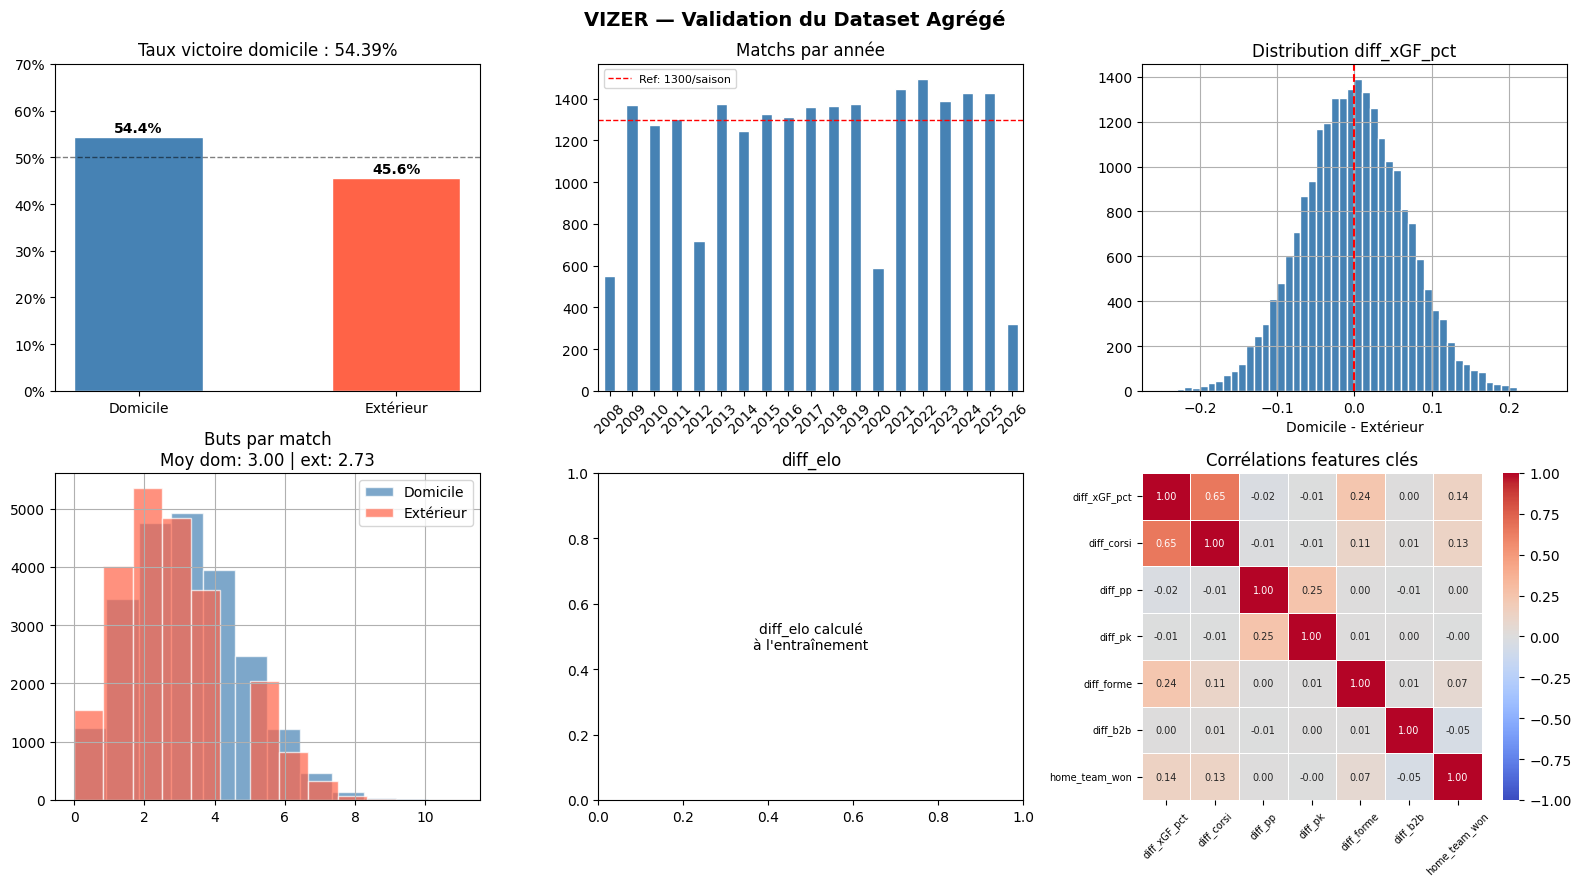

✅ Graphique sauvegardé → agregation_validation.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('VIZER — Validation du Dataset Agrégé', fontsize=14, fontweight='bold')

# 1. Taux victoire domicile
ax = axes[0, 0]
win_rate = df_final['home_team_won'].mean()
ax.bar(['Domicile', 'Extérieur'], [win_rate, 1 - win_rate],
       color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylim(0, 0.7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title(f'Taux victoire domicile : {win_rate:.2%}')
for i, v in enumerate([win_rate, 1-win_rate]):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# 2. Matchs par année
ax = axes[0, 1]
if 'gameDate_home' in df_final.columns:
    df_final['gameDate_home'] = pd.to_datetime(df_final['gameDate_home'])
    by_year = df_final.groupby(df_final['gameDate_home'].dt.year).size()
    by_year.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.axhline(1300, color='red', linestyle='--', linewidth=1, label='Ref: 1300/saison')
    ax.set_title('Matchs par année')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

# 3. Distribution diff_xGF_pct
ax = axes[0, 2]
df_final['diff_xGF_pct'].clip(-0.25, 0.25).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--')
ax.set_title('Distribution diff_xGF_pct')
ax.set_xlabel('Domicile - Extérieur')

# 4. Distribution buts par équipe
ax = axes[1, 0]
df_final['finalGoals_home'].hist(bins=12, ax=ax, alpha=0.7, color='steelblue',
                                  edgecolor='white', label='Domicile')
df_final['finalGoals_away'].hist(bins=12, ax=ax, alpha=0.7, color='tomato',
                                  edgecolor='white', label='Extérieur')
ax.set_title(f'Buts par match\nMoy dom: {df_final["finalGoals_home"].mean():.2f} | ext: {df_final["finalGoals_away"].mean():.2f}')
ax.legend()

# 5. Distribution diff_elo (si calculé)
ax = axes[1, 1]
if 'diff_elo' in df_final.columns:
    df_final['diff_elo'].clip(-300, 300).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Distribution diff_elo')
else:
    ax.text(0.5, 0.5, 'diff_elo calculé\nà l\'entraînement', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('diff_elo')

# 6. Heatmap corrélation features clés
ax = axes[1, 2]
feat_sample = [c for c in ['diff_xGF_pct','diff_corsi','diff_pp','diff_pk',
                             'diff_forme','diff_b2b','home_team_won'] if c in df_final.columns]
corr = df_final[feat_sample].corr()
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Corrélations features clés')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig('agregation_validation.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé → agregation_validation.png')

## 🎯 Fusion period_stats (optionnel — pour Poisson P1 dédié)

Si `02b_Period_Data.ipynb` a généré `period_stats.csv`, on l'utilise pour créer des features P1 réelles.

In [17]:
# Fusion period_stats si disponible (créé par 02b_Period_Data.ipynb)
PERIOD_STATS_FILE = os.path.join(DRIVE_PATH, 'period_stats.csv')
if os.path.exists(PERIOD_STATS_FILE):
    print(f'✅ {PERIOD_STATS_FILE} détecté — intégration des stats P1...')
    period_stats = pd.read_csv(PERIOD_STATS_FILE)
    
    # Diagnostic des types et valeurs avant le merge
    print(f'   📋 period_stats : {len(period_stats):,} lignes')
    print(f'      gameId dtype : {period_stats["gameId"].dtype} | exemples : {period_stats["gameId"].iloc[:3].tolist()}')
    print(f'      team dtype   : {period_stats["team"].dtype} | exemples : {period_stats["team"].iloc[:3].tolist()}')
    print(f'   📋 df_final.gameId_home : {df_final["gameId_home"].dtype} | exemples : {df_final["gameId_home"].iloc[:3].tolist()}')
    print(f'      df_final.team_home   : {df_final["team_home"].dtype} | exemples : {df_final["team_home"].iloc[:3].tolist()}')
    
    # CAST FORCÉ DES TYPES (la cause principale du merge à 0%)
    # gameId : int64 dans les deux DataFrames
    period_stats['gameId']   = pd.to_numeric(period_stats['gameId'], errors='coerce').astype('Int64')
    df_final['gameId_home']  = pd.to_numeric(df_final['gameId_home'], errors='coerce').astype('Int64')
    df_final['gameId_away']  = pd.to_numeric(df_final['gameId_away'], errors='coerce').astype('Int64')
    period_stats = period_stats.dropna(subset=['gameId'])
    
    # Diagnostic d'intersection
    gameIds_ps = set(period_stats['gameId'].unique())
    gameIds_df = set(df_final['gameId_home'].dropna().unique())
    inter = gameIds_ps & gameIds_df
    print(f'   🔍 Intersection gameId : {len(inter):,}/{len(gameIds_df):,} matchs ({len(inter)/max(len(gameIds_df),1):.1%})')
    
    if len(inter) == 0:
        print(f'   ⚠️  Aucune intersection — formats incompatibles. Exemples ps={list(gameIds_ps)[:3]}, df={list(gameIds_df)[:3]}')
        print(f'   ℹ️  Continuation sans P1 réel (fallback approximation activée).')
    else:
        # Garder uniquement P1 (la cible pour notre Poisson P1 dédié)
        p1_stats = period_stats[period_stats['period'] == 1].copy()
        p1_stats = p1_stats.rename(columns={'goals': 'goals_p1', 'xGoals': 'xGoals_p1'})
        p1_stats = p1_stats[['gameId', 'team', 'goals_p1', 'xGoals_p1']]
        
        # Merge home
        df_final = pd.merge(df_final,
                            p1_stats.rename(columns={'goals_p1': 'goals_p1_home',
                                                      'xGoals_p1': 'xGoals_p1_home'}),
                            left_on=['gameId_home', 'team_home'], right_on=['gameId', 'team'],
                            how='left')
        df_final = df_final.drop(columns=['gameId', 'team'], errors='ignore')
        
        # Merge away
        df_final = pd.merge(df_final,
                            p1_stats.rename(columns={'goals_p1': 'goals_p1_away',
                                                      'xGoals_p1': 'xGoals_p1_away'}),
                            left_on=['gameId_away', 'team_away'], right_on=['gameId', 'team'],
                            how='left')
        df_final = df_final.drop(columns=['gameId', 'team'], errors='ignore')
        
        # Stats : combien de matchs ont des données P1 réelles ?
        n_with_p1 = df_final['goals_p1_home'].notna().sum()
        pct = n_with_p1/len(df_final)
        status = '✅' if pct > 0.8 else '⚠️ '
        print(f'   {status} {n_with_p1:,}/{len(df_final):,} matchs ({pct:.1%}) avec données P1 réelles')
        
        # Fillna avec moyenne ligue (~1 but/équipe en P1)
        df_final['goals_p1_home']  = df_final['goals_p1_home'].fillna(1.0)
        df_final['goals_p1_away']  = df_final['goals_p1_away'].fillna(1.0)
        df_final['xGoals_p1_home'] = df_final['xGoals_p1_home'].fillna(1.0)
        df_final['xGoals_p1_away'] = df_final['xGoals_p1_away'].fillna(1.0)
        print(f'   ✅ Features P1 ajoutées au dataset')
else:
    print(f'ℹ️  {PERIOD_STATS_FILE} absent — pas de Poisson P1 dédié.')
    print(f'   Lance 02b_Period_Data.ipynb si tu veux la P1 précise.')

✅ /home/noxtheteenager/Documents/Projets/vizer_info_model/hockey/nhl/period_stats.csv détecté — intégration des stats P1...
   📋 period_stats : 147,040 lignes
      gameId dtype : int64 | exemples : [2007020001, 2007020001, 2007020001]
      team dtype   : str | exemples : ['ANA', 'ANA', 'ANA']
   📋 df_final.gameId_home : int64 | exemples : [2008020030, 2008020048, 2008020061]
      df_final.team_home   : str | exemples : ['ANA', 'ANA', 'ANA']
   🔍 Intersection gameId : 22,663/22,664 matchs (100.0%)
   ✅ 22,663/22,664 matchs (100.0%) avec données P1 réelles
   ✅ Features P1 ajoutées au dataset


## 🤜🤛 Head-to-Head historique

Calcule pour chaque match les stats des 5 derniers affrontements directs entre les deux équipes.
Attention au leakage : on prend uniquement les matchs **antérieurs** à la date courante.

## 🥅 Gardien partant — GSAE rolling

Pour chaque match, identifie le gardien partant (max icetime) et calcule son GSAE (Goals Saved Above Expected) rolling sur 10 derniers matchs comme starter.

In [18]:
# Téléchargement des données gardiens (game-by-game)
GOALIE_FILES = {
    'historique': os.path.join(DRIVE_PATH, 'goalies_2008_2024.csv'),
    'courant':    os.path.join(DRIVE_PATH, 'goalies_2025.csv'),
}

HAS_GOALIE_DATA = all(os.path.exists(f) for f in GOALIE_FILES.values())

if HAS_GOALIE_DATA:
    print('🥅 Traitement des données gardiens (game-by-game)...')
    
    # Détecter les colonnes réelles dans le CSV (Moneypuck change parfois les noms)
    sample_cols = pd.read_csv(GOALIE_FILES['historique'], nrows=0).columns.tolist()
    print(f'   📋 Colonnes disponibles (échantillon) : {sample_cols[:15]}')
    
    # Mapping flexible : on essaie plusieurs noms possibles
    def find_col(candidates, available):
        for c in candidates:
            if c in available:
                return c
        return None
    
    col_gameId   = find_col(['gameId', 'game_id'], sample_cols)
    col_playerId = find_col(['playerId', 'player_id'], sample_cols)
    col_name     = find_col(['name', 'playerName', 'goalie_name'], sample_cols)
    col_team     = find_col(['team', 'teamCode', 'teamAbbrev'], sample_cols)
    col_icetime  = find_col(['icetime', 'iceTime', 'TOI'], sample_cols)
    # Pour goalie, xGoalsAgainst peut être 'xGoals' (perspective gardien) ou autre nom
    col_xga      = find_col(['xGoalsAgainst', 'xGoals', 'xGoalsFor'], sample_cols)
    col_ga       = find_col(['goalsAgainst', 'goals', 'goalsFor'], sample_cols)
    col_situation = find_col(['situation'], sample_cols)
    
    required = {'gameId': col_gameId, 'name': col_name, 'team': col_team,
                'icetime': col_icetime, 'xGA': col_xga, 'GA': col_ga}
    missing = [k for k, v in required.items() if v is None]
    
    if missing:
        print(f'   ❌ Colonnes manquantes : {missing}')
        print(f'   ℹ️  Vérifie {GOALIE_FILES["historique"]} — feature gardien partant désactivée')
        HAS_GOALIE_DATA = False
    else:
        cols_to_read = [c for c in [col_gameId, col_playerId, col_name, col_team,
                                      col_icetime, col_xga, col_ga, col_situation] if c]
        print(f'   ✅ Mapping détecté :')
        for k, v in required.items():
            print(f'      {k:>10} → {v}')
        
        # Chargement avec uniquement les colonnes nécessaires
        g_dfs = []
        for label, path in GOALIE_FILES.items():
            gdf = pd.read_csv(path, usecols=cols_to_read)
            g_dfs.append(gdf)
        goalies_all = pd.concat(g_dfs, ignore_index=True)
        
        # Renommer les colonnes en noms standards pour la suite
        rename_map = {col_gameId: 'gameId', col_name: 'name', col_team: 'team',
                      col_icetime: 'icetime', col_xga: 'xGoalsAgainst', col_ga: 'goalsAgainst'}
        goalies_all = goalies_all.rename(columns=rename_map)
        
        # Filtre situation 'all' si disponible
        if col_situation and col_situation in goalies_all.columns:
            goalies_all = goalies_all[goalies_all[col_situation] == 'all']
        
        # Cast types
        goalies_all['gameId'] = pd.to_numeric(goalies_all['gameId'], errors='coerce').astype('Int64')
        goalies_all['icetime'] = pd.to_numeric(goalies_all['icetime'], errors='coerce').fillna(0)
        goalies_all['xGoalsAgainst'] = pd.to_numeric(goalies_all['xGoalsAgainst'], errors='coerce').fillna(0)
        goalies_all['goalsAgainst']  = pd.to_numeric(goalies_all['goalsAgainst'],  errors='coerce').fillna(0)
        
        # GSAE par match
        goalies_all['gsae_game'] = goalies_all['xGoalsAgainst'] - goalies_all['goalsAgainst']
        
        # Identifier le partant : gardien avec le plus d'icetime par match
        starter_idx = goalies_all.groupby(['gameId', 'team'])['icetime'].idxmax()
        starters = goalies_all.loc[starter_idx].copy()
        starters = starters.sort_values(['name', 'gameId'])
        
        # Rolling GSAE sur 10 derniers matchs (shift(1) anti-leakage)
        starters['goalie_gsae_rolling_10'] = (
            starters.groupby('name')['gsae_game']
            .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
            .fillna(0)
        )
        
        print(f'\n   ✅ {len(starters):,} matchs-équipe avec partant identifié')
        print(f'   ✅ {starters["name"].nunique()} gardiens uniques')
        print(f'   GSAE rolling moy : {starters["goalie_gsae_rolling_10"].mean():.4f}')
        
        # Merge dans df_final
        starters_slim = starters[['gameId', 'team', 'name', 'goalie_gsae_rolling_10']].copy()
        
        df_final['gameId_home'] = pd.to_numeric(df_final['gameId_home'], errors='coerce').astype('Int64')
        df_final['gameId_away'] = pd.to_numeric(df_final['gameId_away'], errors='coerce').astype('Int64')
        
        df_final = pd.merge(df_final,
                            starters_slim.rename(columns={
                                'goalie_gsae_rolling_10': 'goalie_starter_gsae_home',
                                'name': 'goalie_starter_name_home'}),
                            left_on=['gameId_home', 'team_home'],
                            right_on=['gameId', 'team'], how='left')
        df_final = df_final.drop(columns=['gameId', 'team'], errors='ignore')
        
        df_final = pd.merge(df_final,
                            starters_slim.rename(columns={
                                'goalie_gsae_rolling_10': 'goalie_starter_gsae_away',
                                'name': 'goalie_starter_name_away'}),
                            left_on=['gameId_away', 'team_away'],
                            right_on=['gameId', 'team'], how='left')
        df_final = df_final.drop(columns=['gameId', 'team'], errors='ignore')
        
        df_final['goalie_starter_gsae_home'] = df_final['goalie_starter_gsae_home'].fillna(0)
        df_final['goalie_starter_gsae_away'] = df_final['goalie_starter_gsae_away'].fillna(0)
        df_final['diff_goalie_starter_gsae'] = (df_final['goalie_starter_gsae_home'] -
                                                  df_final['goalie_starter_gsae_away'])
        
        n_with_goalie = df_final['goalie_starter_name_home'].notna().sum()
        print(f'   ✅ {n_with_goalie:,}/{len(df_final):,} matchs ({n_with_goalie/len(df_final):.1%}) avec gardien identifié')
        print(f'   std diff_goalie_starter_gsae = {df_final["diff_goalie_starter_gsae"].std():.3f}')
        
        # Sauvegarder pour l'inférence
        starters.to_csv(os.path.join(DRIVE_PATH, 'goalies_rolling_gsae.csv'), index=False)
        print(f'   💾 goalies_rolling_gsae.csv sauvegardé')

if not HAS_GOALIE_DATA:
    print('ℹ️  Données gardiens absentes — lance 01_Maintenance.ipynb')
    print('   La feature diff_goalie_starter_gsae sera à 0 (neutre).')
    df_final['goalie_starter_gsae_home'] = 0.0
    df_final['goalie_starter_gsae_away'] = 0.0
    df_final['diff_goalie_starter_gsae'] = 0.0
    df_final['goalie_starter_name_home'] = None
    df_final['goalie_starter_name_away'] = None

🥅 Traitement des données gardiens (game-by-game)...
   📋 Colonnes disponibles (échantillon) : ['playerId', 'name', 'gameId', 'season', 'playerTeam', 'opposingTeam', 'home_or_away', 'gameDate', 'position', 'situation', 'icetime', 'xGoals', 'goals', 'unblocked_shot_attempts', 'xRebounds']
   ❌ Colonnes manquantes : ['team']
   ℹ️  Vérifie /home/noxtheteenager/Documents/Projets/vizer_info_model/hockey/nhl/goalies_2008_2024.csv — feature gardien partant désactivée
ℹ️  Données gardiens absentes — lance 01_Maintenance.ipynb
   La feature diff_goalie_starter_gsae sera à 0 (neutre).


In [19]:
# Calcul H2H — pour chaque match, regarder les 5 derniers face-à-face entre les 2 équipes
# Implémentation efficace : iteration unique sur les matchs triés par date,
# maintien d'un dict {(team_A, team_B) sorted: list of past results}
print('🤜🤛 Calcul H2H historique (5 derniers affrontements)...')
df_final = df_final.sort_values('gameDate_home').reset_index(drop=True)

h2h_history = {}  # clé: tuple trié (team1, team2), valeur: list of (home_won, goals_h, goals_a)
h2h_features = []

for _, row in df_final[['team_home','team_away','home_team_won',
                          'finalGoals_home','finalGoals_away']].iterrows():
    h, a = row['team_home'], row['team_away']
    key  = tuple(sorted([h, a]))
    past = h2h_history.get(key, [])
    
    # Calculer les features sur les past matchs (avant le match courant)
    if len(past) == 0:
        feat = {'h2h_n_games': 0, 'h2h_home_dominance': 0.0,
                'h2h_avg_total_goals': 5.7}  # défaut ligue
    else:
        # Pour chaque past match, déterminer si "home_team_won" du POV de l'équipe à domicile actuelle
        # Si dans le past match h était à domicile et a gagné → +1 pour h
        # Si dans le past match h était à l'extérieur et a gagné → +1 pour h
        recent = past[-5:]  # derniers 5 affrontements
        h_won_count = 0
        total_goals_sum = 0
        for past_h, past_a, past_h_won, past_goals_h, past_goals_a in recent:
            # past_h_won = 1 si l'équipe à domicile dans ce match passé a gagné
            if past_h == h:
                h_won_count += past_h_won       # h était à domicile et a gagné/perdu
            else:
                h_won_count += (1 - past_h_won) # h était à l'extérieur
            total_goals_sum += past_goals_h + past_goals_a
        
        h2h_home_dominance  = (h_won_count / len(recent)) - 0.5  # centré sur 0
        h2h_avg_total_goals = total_goals_sum / len(recent)
        feat = {'h2h_n_games':           len(recent),
                'h2h_home_dominance':    h2h_home_dominance,
                'h2h_avg_total_goals':   h2h_avg_total_goals}
    h2h_features.append(feat)
    
    # Mettre à jour l'historique APRÈS avoir calculé les features (pas de leakage)
    h2h_history.setdefault(key, []).append(
        (h, a, row['home_team_won'], row['finalGoals_home'], row['finalGoals_away'])
    )

h2h_df = pd.DataFrame(h2h_features)
df_final = pd.concat([df_final.reset_index(drop=True), h2h_df.reset_index(drop=True)], axis=1)

# Stats
n_with_h2h = (df_final['h2h_n_games'] > 0).sum()
print(f'   ✅ H2H calculé : {n_with_h2h:,}/{len(df_final):,} matchs ({n_with_h2h/len(df_final):.1%}) avec ≥1 face-à-face passé')
print(f'   h2h_home_dominance : moy {df_final["h2h_home_dominance"].mean():+.3f} (proche de 0 = équilibré)')
print(f'   h2h_avg_total_goals : moy {df_final["h2h_avg_total_goals"].mean():.2f} buts')

🤜🤛 Calcul H2H historique (5 derniers affrontements)...
   ✅ H2H calculé : 22,168/22,664 matchs (97.8%) avec ≥1 face-à-face passé
   h2h_home_dominance : moy -0.005 (proche de 0 = équilibré)
   h2h_avg_total_goals : moy 5.71 buts


## 📊 Fusion CSA (Score-Adjusted Corsi)

Utilise `csa_stats.csv` produit par `02b_Period_Data.ipynb`. CSA% remplace le Corsi brut qui est biaisé par le score (équipe qui mène défend → Corsi adverse gonflé).

In [20]:
# Fusion CSA si disponible (créé par 02b_Period_Data.ipynb)
CSA_FILE = os.path.join(DRIVE_PATH, 'csa_stats.csv')
if os.path.exists(CSA_FILE):
    print(f'✅ {CSA_FILE} détecté — intégration Score-Adjusted Corsi...')
    csa_stats = pd.read_csv(CSA_FILE)
    csa_stats['gameId'] = pd.to_numeric(csa_stats['gameId'], errors='coerce').astype('Int64')
    
    # Merge home
    df_final['gameId_home'] = pd.to_numeric(df_final['gameId_home'], errors='coerce').astype('Int64')
    df_final['gameId_away'] = pd.to_numeric(df_final['gameId_away'], errors='coerce').astype('Int64')
    
    df_final = pd.merge(df_final,
                        csa_stats.rename(columns={'csa_pct': 'csa_pct_home'})[['gameId','team','csa_pct_home']],
                        left_on=['gameId_home','team_home'], right_on=['gameId','team'], how='left')
    df_final = df_final.drop(columns=['gameId','team'], errors='ignore')
    
    df_final = pd.merge(df_final,
                        csa_stats.rename(columns={'csa_pct': 'csa_pct_away'})[['gameId','team','csa_pct_away']],
                        left_on=['gameId_away','team_away'], right_on=['gameId','team'], how='left')
    df_final = df_final.drop(columns=['gameId','team'], errors='ignore')
    
    n_with_csa = df_final['csa_pct_home'].notna().sum()
    print(f'   {n_with_csa:,}/{len(df_final):,} matchs ({n_with_csa/len(df_final):.1%}) avec CSA')
    
    # Fillna avec 0.5 (neutre)
    df_final['csa_pct_home'] = df_final['csa_pct_home'].fillna(0.5)
    df_final['csa_pct_away'] = df_final['csa_pct_away'].fillna(0.5)
    
    # Rolling CSA% sur 10 matchs (par équipe) — features prédictives
    # On crée un DataFrame temporaire long format pour faire le rolling proprement
    for suffix in ['home', 'away']:
        team_col = f'team_{suffix}'
        csa_col  = f'csa_pct_{suffix}'
        # Trier par équipe et date pour rolling temporel
        df_final = df_final.sort_values([team_col, 'gameDate_home'])
        df_final[f'avg_csa_pct_10_{suffix}'] = (
            df_final.groupby(team_col)[csa_col]
            .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
            .fillna(0.5)
        )
    df_final = df_final.sort_values('gameDate_home').reset_index(drop=True)
    
    # Différentiel CSA glissant
    df_final['diff_csa_pct'] = df_final['avg_csa_pct_10_home'] - df_final['avg_csa_pct_10_away']
    print(f'   ✅ diff_csa_pct calculé (std={df_final["diff_csa_pct"].std():.4f})')
else:
    print(f'ℹ️  {CSA_FILE} absent — lance 02b_Period_Data.ipynb pour activer CSA.')
    df_final['diff_csa_pct'] = 0.0  # neutre

✅ /home/noxtheteenager/Documents/Projets/vizer_info_model/hockey/nhl/csa_stats.csv détecté — intégration Score-Adjusted Corsi...
   22,663/22,664 matchs (100.0%) avec CSA
   ✅ diff_csa_pct calculé (std=0.0533)


## 🎯 Priors P1 par équipe (pour modèle bayésien)

Calcule pour chaque équipe son taux historique de menée en P1 (à domicile et à l'extérieur).
Ces priors seront utilisés à l'inférence pour combiner avec le Poisson P1.

In [21]:
# Calcul des priors P1 par équipe (pour modèle bayésien)
if 'goals_p1_home' in df_final.columns and 'goals_p1_away' in df_final.columns:
    print('🎯 Calcul des priors P1 par équipe...')
    
    team_p1_stats = []
    all_teams = pd.concat([df_final['team_home'], df_final['team_away']]).unique()
    
    for team in all_teams:
        # Matchs à domicile : combien de fois l'équipe a mené à la fin de P1 ?
        home_matches = df_final[df_final['team_home'] == team]
        if len(home_matches) > 0:
            home_led = (home_matches['goals_p1_home'] > home_matches['goals_p1_away']).sum()
            home_lead_rate = home_led / len(home_matches)
        else:
            home_lead_rate = 0.33
        
        # Matchs à l'extérieur : combien de fois mené ?
        away_matches = df_final[df_final['team_away'] == team]
        if len(away_matches) > 0:
            away_led = (away_matches['goals_p1_away'] > away_matches['goals_p1_home']).sum()
            away_lead_rate = away_led / len(away_matches)
        else:
            away_lead_rate = 0.33
        
        team_p1_stats.append({
            'team':                team,
            'home_p1_lead_rate':   round(home_lead_rate, 4),
            'away_p1_lead_rate':   round(away_lead_rate, 4),
            'n_home_games':        len(home_matches),
            'n_away_games':        len(away_matches),
            'n_games':             len(home_matches) + len(away_matches),
        })
    
    team_p1_priors_df = pd.DataFrame(team_p1_stats).sort_values('team')
    team_p1_priors_df.to_csv(os.path.join(DRIVE_PATH, 'team_p1_priors.csv'), index=False)
    
    print(f'   ✅ {len(team_p1_priors_df)} équipes : priors sauvegardés dans team_p1_priors.csv')
    print(f'   Home P1 lead rate moyen : {team_p1_priors_df["home_p1_lead_rate"].mean():.1%}')
    print(f'   Away P1 lead rate moyen : {team_p1_priors_df["away_p1_lead_rate"].mean():.1%}')
    
    # Top/Bottom 3 pour vérifier
    top3 = team_p1_priors_df.nlargest(3, 'home_p1_lead_rate')[['team','home_p1_lead_rate','n_home_games']]
    print(f'\n   Top 3 équipes (P1 lead à domicile) :')
    for _, r in top3.iterrows():
        print(f'      {r["team"]}: {r["home_p1_lead_rate"]:.1%} ({r["n_home_games"]} matchs)')
else:
    print('ℹ️  goals_p1_* absent — pas de priors P1 calculés (lance 02b_Period_Data.ipynb d\'abord)')

🎯 Calcul des priors P1 par équipe...
   ✅ 32 équipes : priors sauvegardés dans team_p1_priors.csv
   Home P1 lead rate moyen : 34.8%
   Away P1 lead rate moyen : 30.1%

   Top 3 équipes (P1 lead à domicile) :
      PIT: 40.0% (775 matchs)
      VGK: 39.5% (395 matchs)
      BOS: 39.0% (789 matchs)


In [22]:
# ── Sauvegarde & résumé validation ───────────────────────────────────────────
df_final.to_csv(OUTPUT_DATASET, index=False)

validation = {
    'Matchs': f'{len(df_final):,}',
    'Colonnes': str(len(df_final.columns)),
    'Home win rate': f'{df_final["home_team_won"].mean():.2%}',
    'Équipes': str(df_final['team_home'].nunique() if 'team_home' in df_final.columns else '?'),
    'NaN restants': str(df_final.isna().sum().sum()),
    'Buts dom (moy)': f'{df_final["finalGoals_home"].mean():.3f}',
    'Buts ext (moy)': f'{df_final["finalGoals_away"].mean():.3f}',
}
df_val = pd.DataFrame(list(validation.items()), columns=['Métrique', 'Valeur'])
display(df_val.style.hide(axis='index').set_caption('✅ Dataset généré avec succès'))
print(f'\n✅ DATASET SAUVEGARDÉ → {OUTPUT_DATASET}')
print('➡️  Lance maintenant 03_Entrainement.ipynb')

Métrique,Valeur
Matchs,"22,664"
Colonnes,406
Home win rate,54.39%
Équipes,32
NaN restants,45328
Buts dom (moy),2.999
Buts ext (moy),2.734



✅ DATASET SAUVEGARDÉ → dataset_agrege_vizer_nhl.csv
➡️  Lance maintenant 03_Entrainement.ipynb
